# GLMs in RStan III
# Gamma Regression

This article is part of a series:

- <a href="">GLMs in RStan I - Poisson and ZIP Regression</a>
- <a href="">GLMs in RStan II - Negative Binomial and ZINB Regression</a>
- <a href="">GLMs in RStan III - Gamma Regression</a>
- <a href="">GLMs in RStan IV - Summary</a>

You may also be interested in <a href="">Bayesian Modeling in RStan</a>.

# Outline

<ul>
<li>The Gamma Distribution</li>
</br>
<li>Recap - Generalized Linear Models (GLMs)</li>
</br>
<li>Gamma Regression Implementation</li>
<ul>
    <li>The <code>mtcars</code> Dataset</li>
</ul>
</br>
<li>Doing it With Priors</li>
</ul>

This will be a short article compared to the previous - no zero-inflation, no Gaussian mixtures, just a form of regression where the outcome is constrained to positive real numbers. This is as opposed to normal regression, which can produce negatives, and Poisson or negative binomial models, which are constrained to produce integer outcomes. The gamma distribution is also quite flexible, as it has both a shape parameter and rate parameter, and is capable of handling long-tailed skew.

# The Gamma Distribution

The Gamma distribution is used to model continuous variables that are always positive and have skewed distributions. It is a generalization of the Exponential (and Chi-Square) distribution, but while an Exponential random variables represents the waiting time for the first success under conditions of memoryless, the Gamma distribution gives us the waiting time until a number of successes occur. The total waiting time for $n$ arrivals is distributed $Gamma(n, \lambda)$.

<u><i>PDF:</i></u>

$f(x) = \frac{1}{\Gamma(\alpha)} (\beta x)^\alpha e^{-\beta x} \frac{1}{x}$

$\Gamma$ is the Gamma function:

- $\Gamma(a) = \int_0^{\infty} x^a e^{-x} \frac{dx}{x}, a \gt 0$

- $\Gamma(n) = (n-1)!$ if $n$ is a positive integer.

The expected Value is $\frac{\alpha}{\lambda}$ and the variance is $\frac{\alpha}{\lambda^2}$.

The $\alpha$ and $\beta$ parameters are often referred to as the shape and rate parameter respectively. I will refer to them as such, and continue to let alpha refer to our regression intercept, and beta refer to our regression slope.

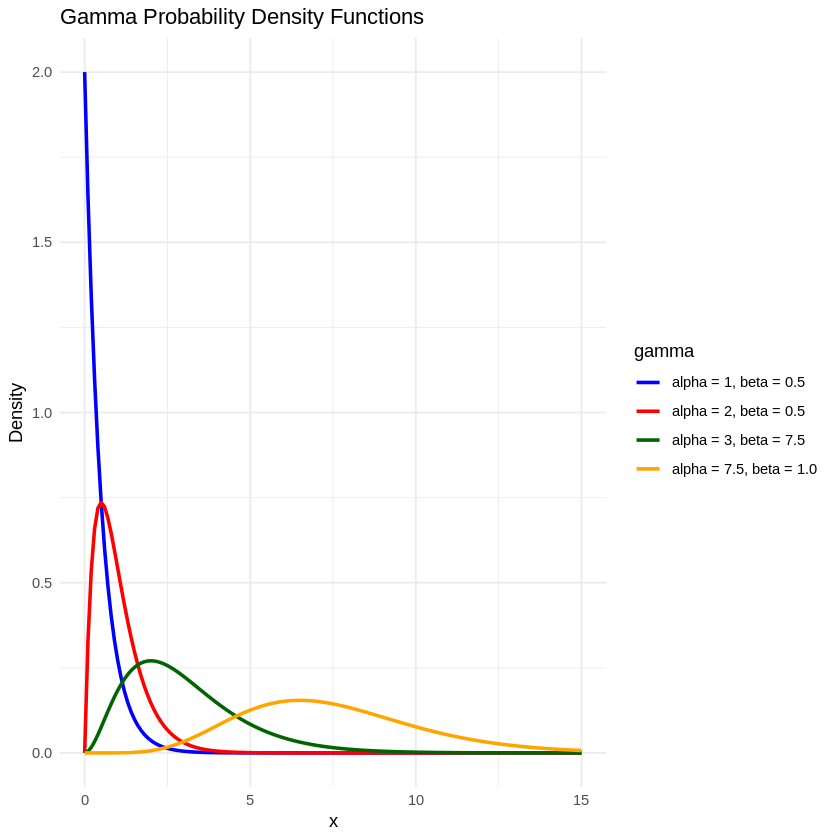

In [1]:
library(ggplot2)

params <- data.frame(
  alpha = c(1, 2, 3, 7.5),
  beta = c(0.5, 0.5, 1.0, 1.0),
  gamma = c("alpha = 1, beta = 0.5",
            "alpha = 2, beta = 0.5",
            "alpha = 3, beta = 7.5",
            "alpha = 7.5, beta = 1.0")
)

x_values <- seq(0, 15, by = 0.1)

# create PDFs
pdf_data <- do.call(rbind, lapply(1:nrow(params), function(i) {
  data.frame(x = x_values,
             y = dgamma(x_values, shape = params$alpha[i], rate = 1 / params$beta[i]),
             gamma = params$gamma[i])
}))

# plot
ggplot(pdf_data, aes(x = x, y = y, color = gamma)) +
  geom_line(linewidth = 1) +
  labs(title = "Gamma Probability Density Functions",
       x = "x",
       y = "Density") +
  theme_minimal() +
  scale_color_manual(values = c("blue", "red", "darkgreen", "orange"))  # Customize colors if desired

# Recap - Generalized Linear Models (GLMs)

As discussed in the previous article, a generalized linear model allows the use of custom distributions for the likelihood. We write
$Y \sim \phi(f(\mu), \theta)$, where $\phi$ is an arbitrary distribution, and $\theta$ represents auxiliary parameters, such as $\sigma$ for the normal distribution. $f$ is called the inverse link function, and when using a distribution constrained to positive values, we typically use a log-link function to connect the linear predictor of the mean to the response variable, while ensuring that the constraint is met.

# Gamma Regression Implementation

## <code>mtcars</code> Dataset

We'll model miles per gallon as a function of horsepower using the well-known <code>mtcars</code> dataset built into R. We'll model the 'shape' ($\alpha$) term of the distribution of <code>mpg</code> as a linear function of <code>hp</code>, only with a log-link function (which means implementing exponential functions). It's essentially the same recipe we used with Poisson regression.

In [ ]:
# install.packages("BiocManager")
# library("BiocManager")

# BiocManager::install("rstan")
# BiocManager::install("GGally")
# BiocManager::install("boot")

library(rstan)
library(GGally) # for pair plots
library(boot) # for bootstrapping
library(MASS) # for GLMs

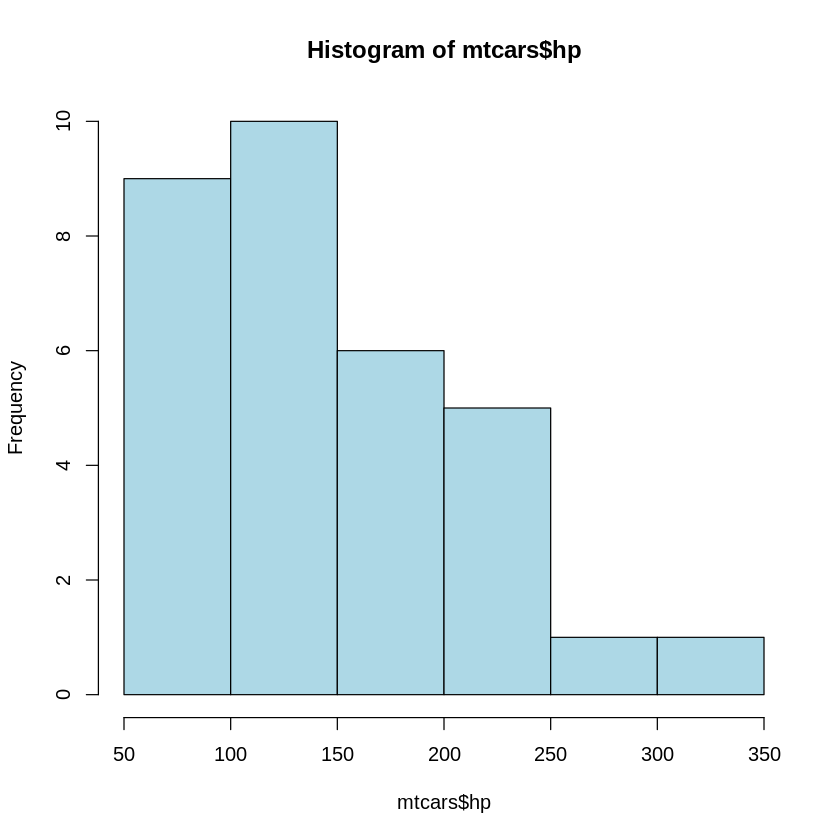

In [3]:
hist(mtcars$hp, breaks=10, col="lightblue")

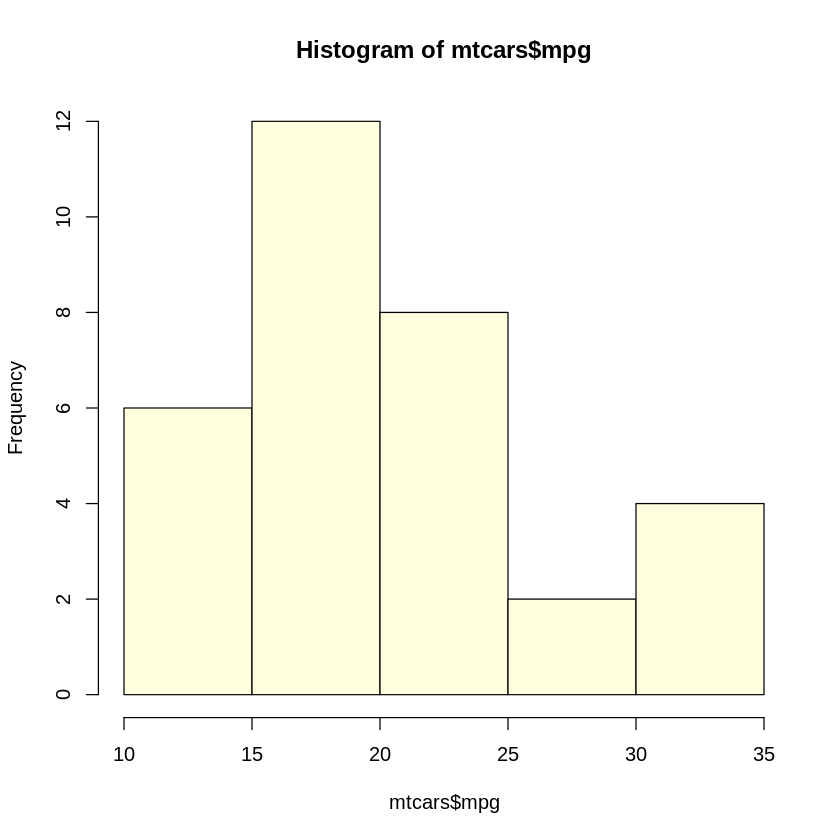

In [4]:
hist(mtcars$mpg, breaks = 8, col="lightyellow")

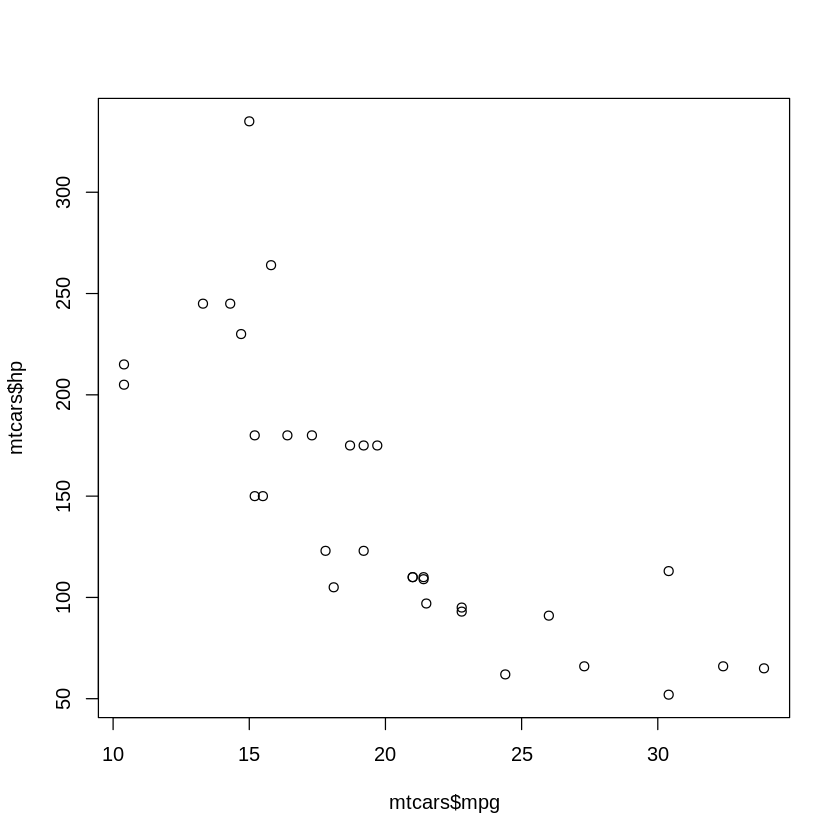

In [5]:
plot(mtcars$mpg, mtcars$hp)

Our <code>stan</code> code, sans priors, is as follows:

In [6]:
stan_code <- "

data {
  int<lower=0> N;
  vector[N] x;
  vector<lower=0>[N] y;
}

parameters {
  real alpha, beta;
  real<lower=0> x_shape, x_rate;
  real<lower=0> y_rate;
}

model {
  x ~ gamma(x_shape, x_rate);
  y ~ gamma(exp(alpha + beta * x), y_rate);
}

generated quantities {
  vector[N] x_pred;
  vector[N] y_pred;

  for (n in 1:N) {
    x_pred[n] = gamma_rng(x_shape, x_rate);
    y_pred[n] = gamma_rng(exp(alpha + beta * x_pred[n]), y_rate);
  }
}
"

In [ ]:
x <- mtcars$hp
y <- mtcars$mpg

N <- length(x)
data_list <- list(N = N, x = x, y = y)
model_fit <- stan(model_code = stan_code, data = data_list, warmup = 2500,
                 iter = 3000, chains = 3, refresh = 0, cores = 8)

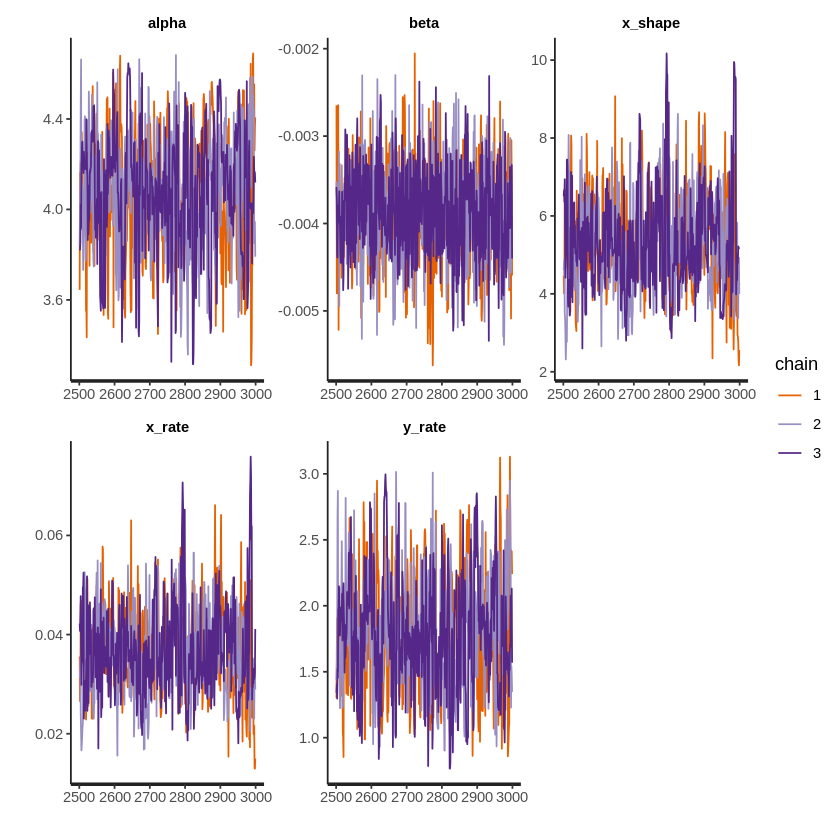

In [11]:
traceplot(model_fit, pars =  c('alpha', 'beta', 'x_shape', 'x_rate', 'y_rate'))

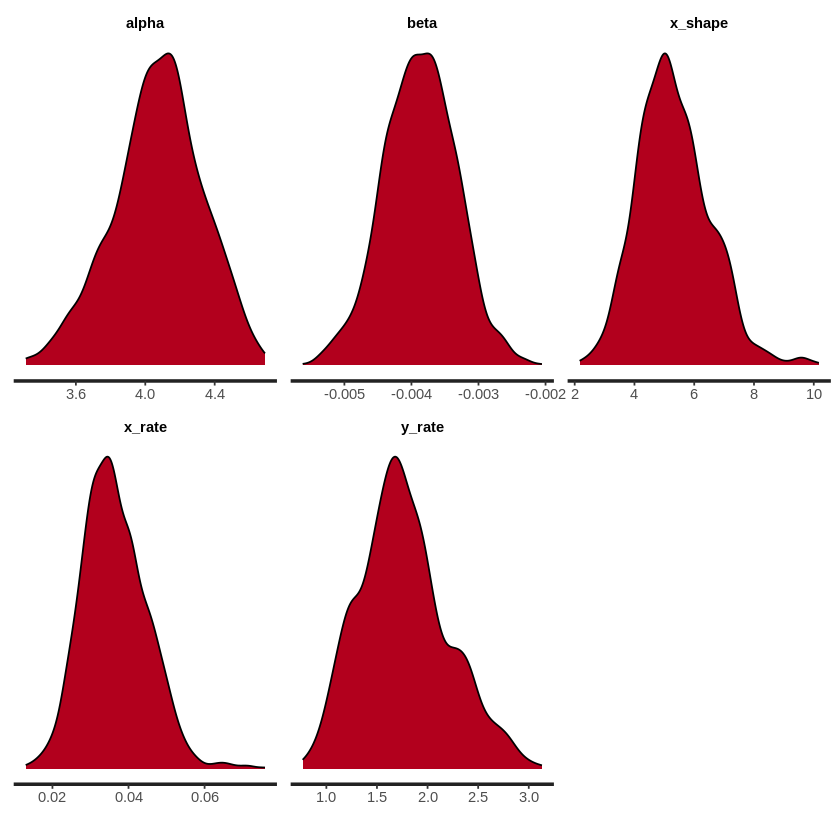

In [12]:
stan_dens(model_fit, pars =  c('alpha', 'beta', 'x_shape', 'x_rate', 'y_rate'))

I found that increasing the number of warmup iterations was necessary to improve stability and avoid warnings. Now, we'll extract the generate samples,

In [13]:
posterior_samples <- rstan::extract(model_fit)

And visualize the results.

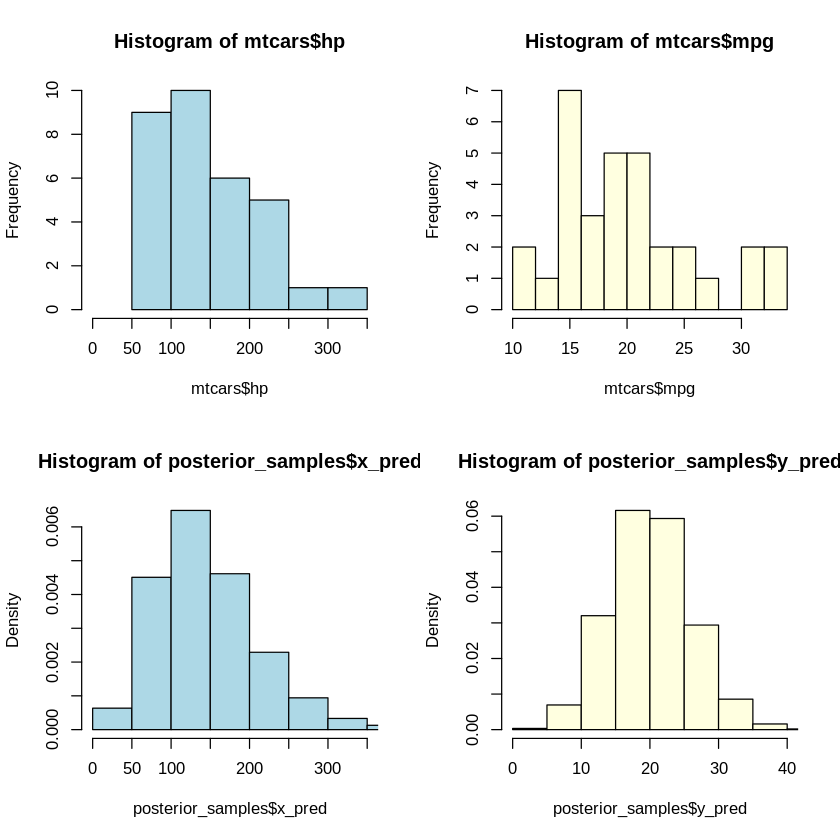

In [14]:
par(mfrow=c(2,2))
hist(mtcars$hp, breaks=10, col="lightblue", xlim=c(0,350))
hist(mtcars$mpg, breaks=10, col="lightyellow")
hist(posterior_samples$x_pred, breaks=15, col="lightblue", probability = TRUE, xlim=c(0,350))
hist(posterior_samples$y_pred, breaks=10, col="lightyellow", probability = TRUE, xlim=c(0,40))

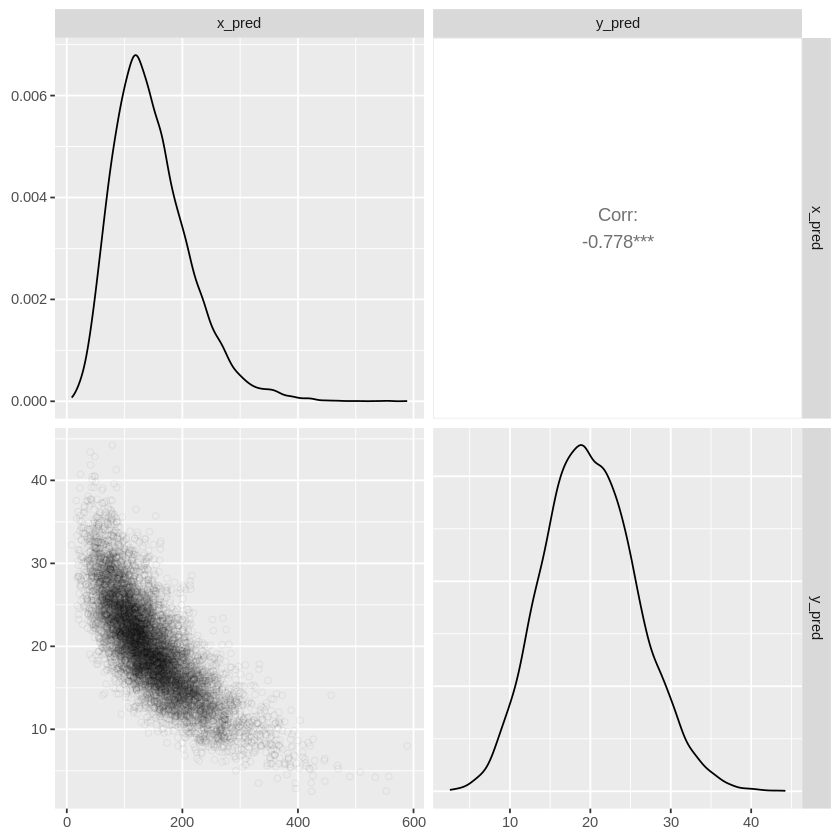

In [15]:
pred_df <- data.frame(x_pred = as.vector(posterior_samples$x_pred),
                      y_pred = as.vector(posterior_samples$y_pred))
sampled_df <- na.omit(pred_df[sample(1:nrow(pred_df), size = 10000), ])
ggpairs(sampled_df,
        lower = list(continuous = wrap("points", alpha = 0.05, shape = 1)),)

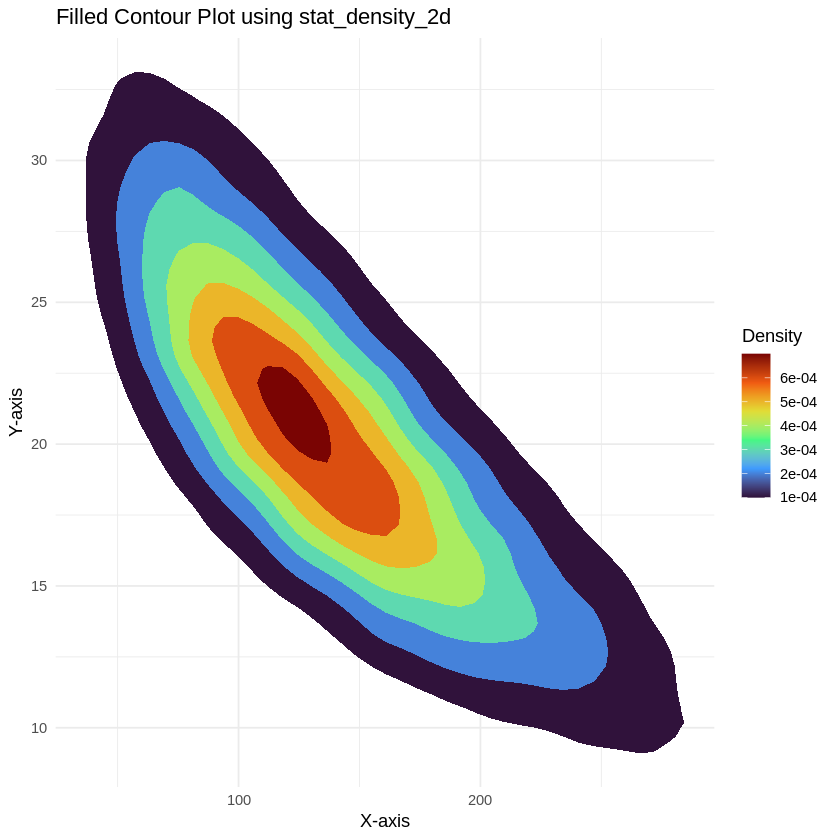

In [16]:
ggplot(na.omit(pred_df), aes(x = x_pred, y = y_pred)) +
  stat_density_2d(aes(fill = after_stat(level)), geom = "polygon") +
  scale_fill_viridis_c(option = "turbo") +  # Optional: for a nicer color scale
  theme_minimal() +
  labs(title = "Filled Contour Plot using stat_density_2d",
       x = "X-axis", y = "Y-axis", fill = "Density")

# Doing it With Priors

As with the prior two articles, I will determine which priors to set by bootstrapping the data. It's not necessarily the best choice, but it will do. First, we fit gamma models to 1000 iterations of the x variable:

In [ ]:
boot_gamma <- function(data, indices) {
  sample_data <- data[indices]
  fit <- fitdistr(sample_data, "gamma")
  shape <- fit$estimate["shape"]
  rate <- fit$estimate["rate"]

  return(c(shape = shape, rate = rate))
}

bootstrap_results <- boot(mtcars$hp, statistic = boot_gamma, R = 1000)

boot_shape <- bootstrap_results$t[,1]
boot_rate <- bootstrap_results$t[,2]

And capture the results into variables.

In [18]:
x_shape_mean <- mean(boot_shape)
x_shape_sd <- sd(boot_shape)
x_rate_mean <- mean(boot_rate)
x_rate_sd <- sd(boot_rate)

print(x_shape_mean, digits=3)
print(x_shape_sd, digits=3)
print(x_rate_mean, digits=3)
print(x_rate_sd, digits=3)

[1] 5.18
[1] 1.04
[1] 0.0356
[1] 0.00817


Next, we create a function to bootstrap a gamma regression, and call upon it 1000 times to receive a list of alpha (intercept) and beta (slope) parameters, as well as the rate parameter of the y variable, called <code>y_rate</code>.

In [ ]:
fit_gamma_reg <- function(data) {
  fit <- glm(mpg ~ hp, family = Gamma(link = "log"), data = data)
  y_alpha_est <- coef(fit)[1]
  y_beta_est <- coef(fit)[2]
  y_phi_est <- fitdistr(fit$residuals^2, "gamma")$estimate["shape"]

  return(c(y_alpha = y_alpha_est, y_beta = y_beta_est, y_phi = y_phi_est))
}

boot_gamma_reg <- function(data, indices) {
  boot_data <- data[indices, ]
  return(fit_gamma_reg(boot_data))
}

bootstrap_results <- boot(mtcars, statistic = boot_gamma_reg, R = 1000)

boot_alpha <- bootstrap_results$t[,1]
boot_beta  <- bootstrap_results$t[,2]
boot_y_rate   <- bootstrap_results$t[,3]

Then we capture the summary statistics in variables,

In [21]:
alpha_mean <- mean(boot_alpha)
alpha_sd <- sd(boot_alpha)
beta_mean <- mean(boot_beta)
beta_sd <- sd(boot_beta)
y_rate_mean <- mean(boot_y_rate)
y_rate_sd <- sd(boot_y_rate)

print(alpha_mean, digits=3)
print(alpha_sd, digits=3)
print(beta_mean, digits=3)
print(beta_sd, digits=3)
print(y_rate_mean, digits=3)
print(y_rate_sd, digits=3)

[1] 3.48
[1] 0.0896
[1] -0.00346
[1] 0.000667
[1] 0.488
[1] 0.138


Our <code>stan</code> code lists these extra parameters in the <code>data{}</code> block, and you can see that all the parameters of the <code>x</code> and <code>y</code> variables have been given priors.

In [22]:
stan_code <- "

data {
  int<lower=0> N;
  vector<lower=0>[N] x;
  vector<lower=0>[N] y;
  real<lower=0> x_shape_mean, x_shape_sd;
  real<lower=0> x_rate_mean, x_rate_sd;
  real alpha_mean, alpha_sd;
  real beta_mean, beta_sd;
  real<lower=0> y_rate_mean;
  real<lower=0> y_rate_sd;
}

parameters {
  real<lower=0> x_shape, x_rate;
  real alpha, beta;
  real<lower=0> y_rate;
}

model {
  x_shape ~ normal(x_shape_mean, x_shape_sd);
  x_rate ~ normal(x_rate_mean, x_rate_sd);
  alpha ~ normal(alpha_mean, alpha_sd);
  beta ~ normal(beta_mean, beta_sd);
  y_rate ~ normal(y_rate_mean, y_rate_sd);
  x ~ gamma(x_shape, x_rate);
  y ~ gamma(exp(alpha + beta * x), y_rate);
}

generated quantities {
  vector[N] x_pred;
  vector[N] y_pred;

  for (n in 1:N) {
    x_pred[n] = gamma_rng(x_shape, x_rate);
    y_pred[n] = gamma_rng(exp(alpha + beta * x_pred[n]), y_rate);
  }
}
"

We pass all these new parameter values to the <code>data_list</code> and fit the model.

In [ ]:
x <- mtcars$hp
y <- mtcars$mpg

N <- length(x)
data_list <- list(N = N, x = x, y = y,
                  x_shape_mean = x_shape_mean,
                  x_shape_sd = x_shape_mean,
                  x_rate_mean = x_rate_mean,
                  x_rate_sd = x_rate_sd,
                  alpha_mean = alpha_mean,
                  alpha_sd = alpha_sd,
                  beta_mean = beta_mean,
                  beta_sd = beta_sd,
                  y_rate_mean = y_rate_mean,
                  y_rate_sd = y_rate_sd)
model_fit <- stan(model_code = stan_code, data = data_list, warmup = 2500,
                 iter = 3000, chains = 3, refresh = 0, cores = 8)

Then check diagnostics,

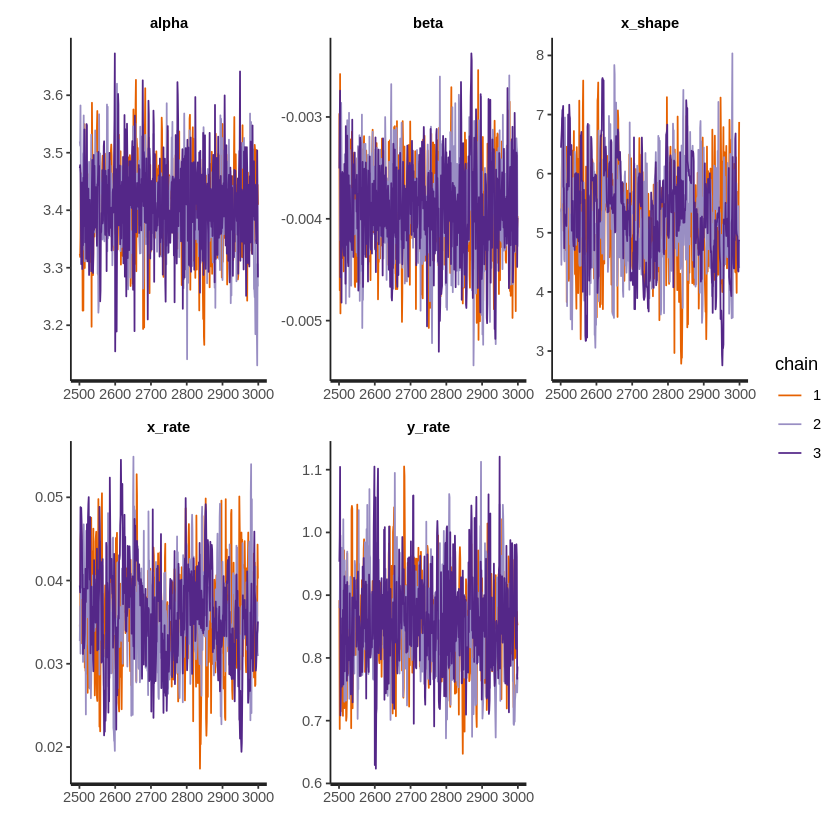

In [25]:
traceplot(model_fit, pars =  c('alpha', 'beta', 'x_shape', 'x_rate', 'y_rate'))

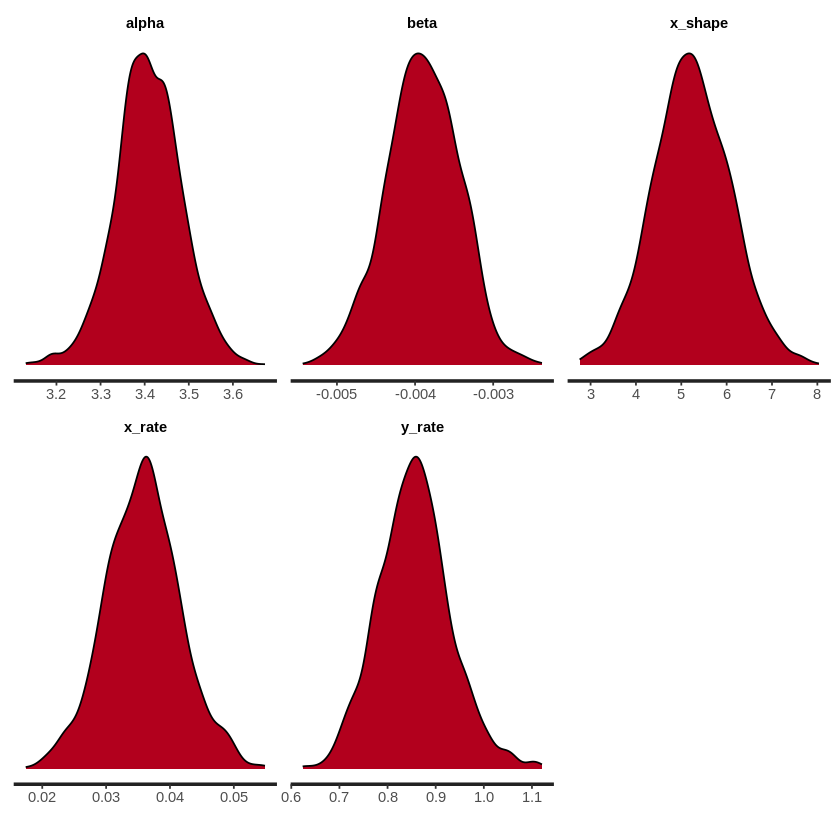

In [27]:
stan_dens(model_fit, pars =  c('alpha', 'beta', 'x_shape', 'x_rate', 'y_rate'))

Extract posterior samples,

In [28]:
posterior_samples <- rstan::extract(model_fit)

And visualize the results.

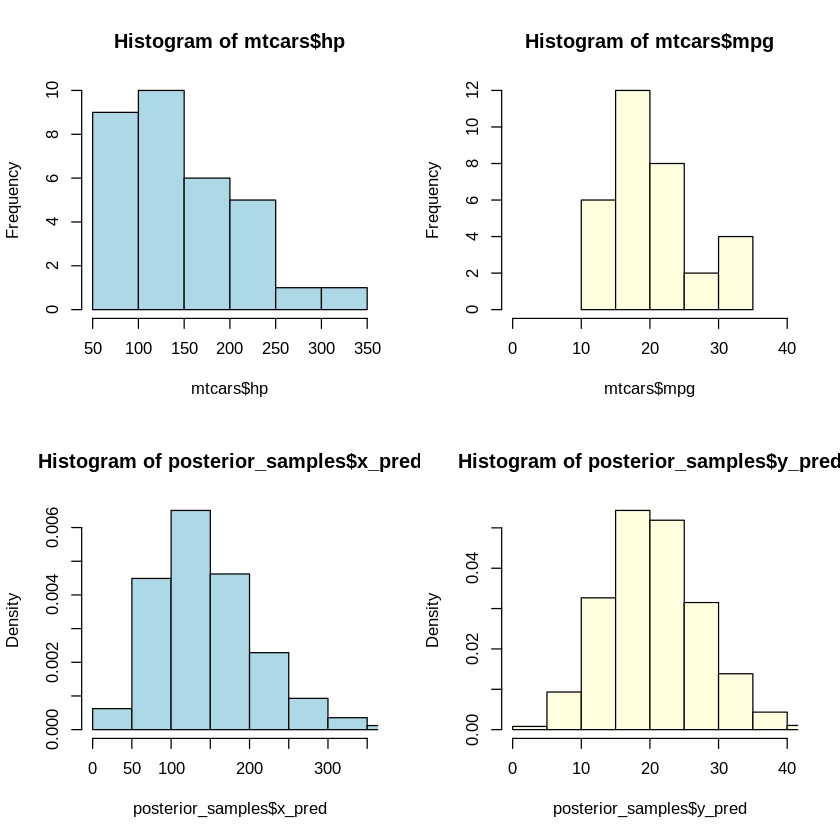

In [30]:
par(mfrow=c(2,2))
hist(mtcars$hp, breaks=8, col="lightblue")
hist(mtcars$mpg, breaks=8, col="lightyellow", xlim=c(0,40))
hist(posterior_samples$x_pred, breaks=15, col="lightblue", probability = TRUE, xlim=c(0,350))
hist(posterior_samples$y_pred, breaks=10, col="lightyellow", probability = TRUE, xlim=c(0,40))

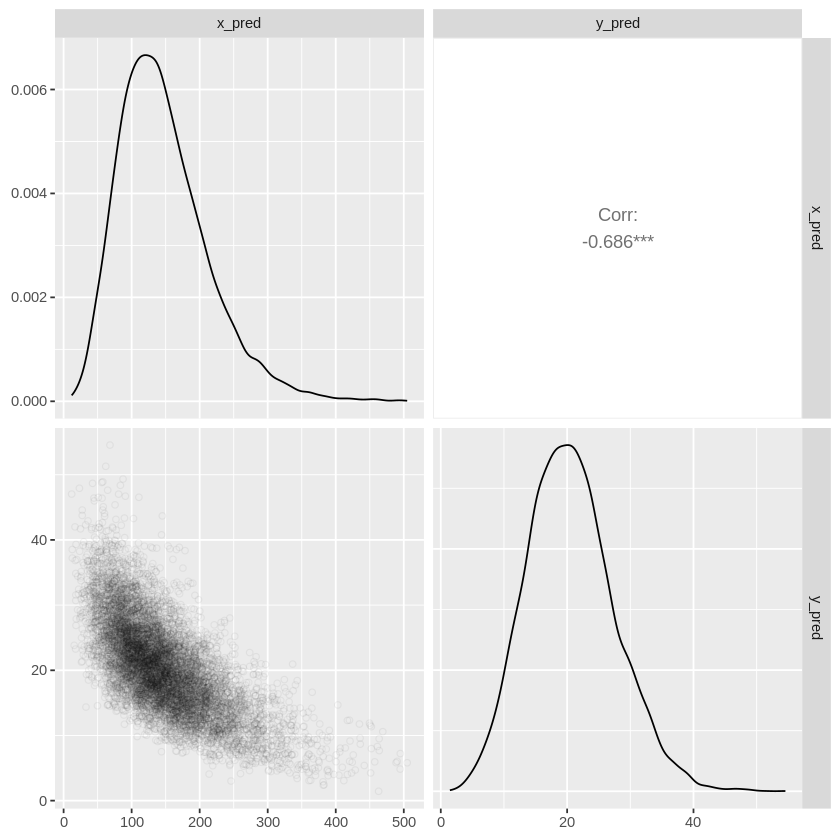

In [31]:
pred_df <- data.frame(x_pred = as.vector(posterior_samples$x_pred),
                      y_pred = as.vector(posterior_samples$y_pred))
sampled_df <- na.omit(pred_df[sample(1:nrow(pred_df), size = 10000), ])
ggpairs(sampled_df,
        lower = list(continuous = wrap("points", alpha = 0.05, shape = 1)),)

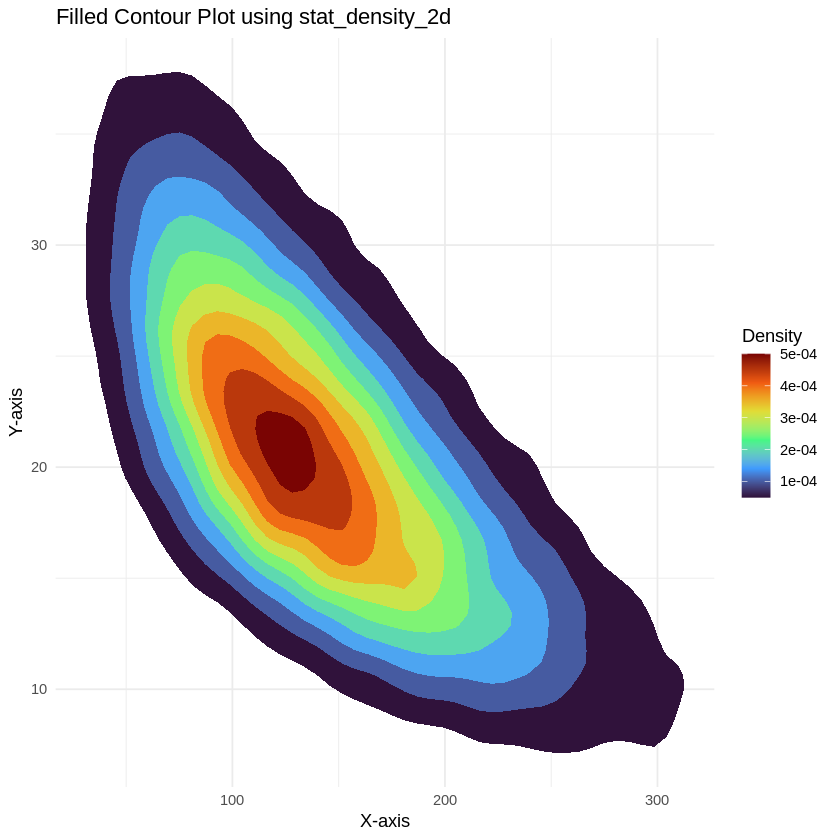

In [32]:
ggplot(na.omit(pred_df), aes(x = x_pred, y = y_pred)) +
  stat_density_2d(aes(fill = after_stat(level)), geom = "polygon") +
  scale_fill_viridis_c(option = "turbo") +  # Optional: for a nicer color scale
  theme_minimal() +
  labs(title = "Filled Contour Plot using stat_density_2d",
       x = "X-axis", y = "Y-axis", fill = "Density")

That concludes this three-part series on GLMs in RStan. Topics we haven't yet touched on include comparing models, and sampler diagnostics; I was mainly concerned with providing a set of templates for the regression procedures. You should become familiar with sampler diagnostic tools (such as trace plots) if you are not already, and employ them in your workflow.

# References

- Stan User Guide https://mc-stan.org/docs/stan-users-guide/index.html